# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List
from dotenv import load_dotenv

load_dotenv() 

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice, chain_of_thought
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [2]:
# OpenAI models — OPENAI_API_KEY is loaded from .env above.
# gpt-4o-mini: smaller, faster, cheaper (MODEL_A / baseline)
# gpt-4o     : larger, stronger          (MODEL_B / comparison)
MODEL_A = "openai/gpt-5-mini"
MODEL_B = "openai/gpt-5"
# I only have ability to use OpenAI models since local inference is long and I don't have credits for other vendors

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [3]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [4]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [ ]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")

MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "college_mathematics"
)

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 100 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [6]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [7]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : openai/gpt-5-mini
Accuracy: 0.6


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [ ]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).
    """
    rows = []
    for sample in log.samples:
        score_obj = next(iter(sample.scores.values()))
        score = 1 if score_obj.value == "C" else 0
        rows.append({
            "id":      sample.id,
            "epoch":   sample.epoch - 1,          
            "score":   score,
            "subject": (sample.metadata or {}).get("subject", ""),
        })
    return pd.DataFrame(rows)

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score    subject
0   1      0      1  astronomy
1   2      0      0  astronomy
2   3      0      1  astronomy
3   4      0      0  astronomy
4   5      0      0  astronomy

Accuracy: 60.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [ ]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1)
    """
    n = len(scores)
    p_hat = float(np.mean(scores))
    se = np.sqrt(p_hat * (1.0 - p_hat) / n)   
    z = stats.norm.ppf(1.0 - (1.0 - ci) / 2.0)
    lower = float(np.clip(p_hat - z * se, 0.0, 1.0))
    upper = float(np.clip(p_hat + z * se, 0.0, 1.0))
    return lower, p_hat, upper


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1)
    """
    per_q = df.groupby("id")["score"].mean().values
    n = len(per_q)
    mu = float(np.mean(per_q))
    se = float(np.std(per_q, ddof=0)) / np.sqrt(n)
    z = stats.norm.ppf(1.0 - (1.0 - ci) / 2.0)
    lower = float(np.clip(mu - z * se, 0.0, 1.0))
    upper = float(np.clip(mu + z * se, 0.0, 1.0))
    return lower, mu, upper

In [10]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.223  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Running K=10 evaluation on MY_SUBSET (reused for 4.1 and 4.2) ...


Output()

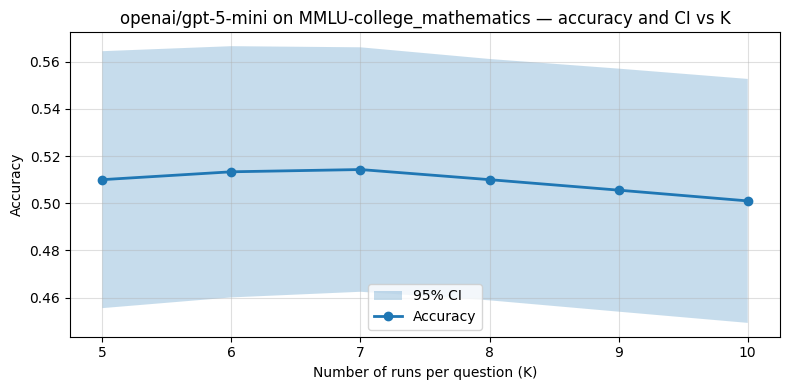

In [ ]:
print("Running K=10 evaluation on MY_SUBSET (reused for 4.1 and 4.2) ...")
logs_kmax = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=10)
df_kmax = log_to_df(logs_kmax[0])

k_values  = [5, 6, 7, 8, 9, 10]
accuracies = []
ci_lowers  = []
ci_uppers  = []

for k in k_values:
    df_k = df_kmax[df_kmax["epoch"] < k]
    lower, acc, upper = ci_accuracy(df_k)
    accuracies.append(acc)
    ci_lowers.append(lower)
    ci_uppers.append(upper)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-college_mathematics — accuracy and CI vs K")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

1. The CI band narrows meaningfully from K=5 to K=8, visually the shaded region shrinks noticeably over those steps. From K=8 onward the improvement becomes marginal: the band width changes very little between K=8, 9, and 10. Running past K=8 is unlikely to justify the cost (roughly 17 minutes for K=10 on 100 questions, so each additional epoch is ~1.7 min with diminishing statistical returns).

2. Just the confidence. The accuracy line stays nearly flat around 0.50–0.515 across all K values. More runs per question only tighten the CI band, not the underlying measured accuracy. This is exactly what you'd expect: K averages out stochastic noise but doesn't change the model's true performance.

3. Spend budget on more unique questions, not more runs per question. Once K >= 7–8, additional epochs return diminishing CI narrowing. The same token budget spent on evaluating 50 new questions would give genuinely independent observations and reduce uncertainty in a way that more K cannot replicate. The practical rule: set K=5–6 as a baseline for stochastic models, then redirect remaining budget to broader question coverage.

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

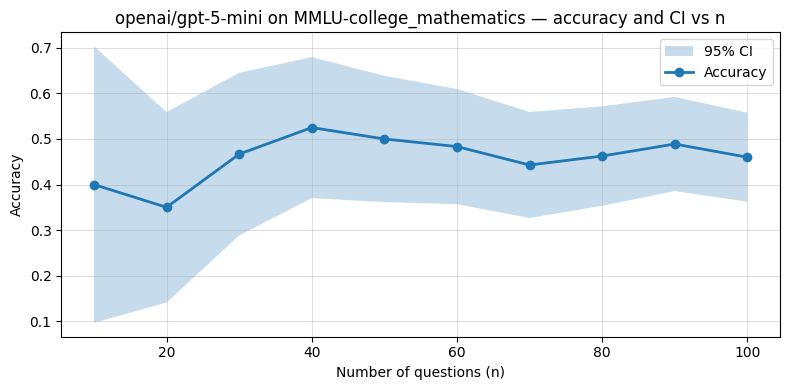

In [12]:
# Reuse df_kmax from 4.1; use only epoch=0 (single run per question) for n-variation.
df_k1 = df_kmax[df_kmax["epoch"] == 0]
question_ids = df_k1["id"].unique()   # all question IDs from the full run

dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies = []
ci_lowers  = []
ci_uppers  = []

for n in dataset_sizes:
    df_n = df_k1[df_k1["id"].isin(question_ids[:n])]
    lower, acc, upper = ci_accuracy(df_n)
    accuracies.append(acc)
    ci_lowers.append(lower)
    ci_uppers.append(upper)

plt.figure(figsize=(8, 4))
plt.fill_between(list(dataset_sizes), ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(list(dataset_sizes), accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-college_mathematics — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**

1. Around n ~ 50–60. Before that (n < 40) the line swings wildly — from 0.40 down to 0.35, then up to 0.53. From n=50 onward the oscillations shrink noticeably and the line settles into the 0.44–0.50 range. The CI band also stops touching 0.1 and narrows to a consistently moderate width.

2. MY_SUBSET has 100 questions, which is comfortably past the stabilization threshold of ~50–60. We are in the reliable region, the CI at n=100 is roughly [0.38, 0.54], a width of ~16 pp. That is acceptable for detecting large differences between models, though tight comparisons still require more data.

3. Both reduce uncertainty, but differently. More n adds genuinely independent observations, it stabilizes the point estimate itself (the accuracy line visibly bounces at low n and settles at high n) and shrinks the CI at 1/sqrt(n). More K only averages out run-to-run noise on the same questions, the accuracy line in 4.1 stayed flat throughout, K never moved the estimate, only narrowed the band slightly. For a fixed budget, more questions always dominates more runs.

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [13]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"

    alternative = "two-sided" if two_tailed else "greater"
    mean_diff   = float(np.mean(scores1 - scores2))

    _, p_value  = stats.ttest_rel(scores1, scores2, alternative=alternative)

    # Degenerate case: zero variance in differences (e.g. all identical)
    # → t-statistic is ±inf; scipy returns NaN; handle explicitly.
    if np.isnan(p_value):
        p_value = 0.0 if mean_diff != 0.0 else 1.0

    return float(p_value), mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [14]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


C:\Users\nikuz\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
print("Comparing models on MY_SUBSET ...")
scores_a = run_and_get_scores(MODEL_A, MY_SUBSET)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET)

p_val, mean_diff, is_sig = significance_by_paired_ttest(scores_a, scores_b)

print(f"\nPaired t-test: {MODEL_A}  vs  {MODEL_B}")
print(f"  MODEL_A accuracy : {np.mean(scores_a):.1%}")
print(f"  MODEL_B accuracy : {np.mean(scores_b):.1%}")
print(f"  Mean diff (A−B)  : {mean_diff:+.4f}")
print(f"  p-value          : {p_val:.4f}")
print(f"  Significant?     : {is_sig}  (α = 0.05)")

Output()

Comparing models on MY_SUBSET ...
  Running openai/gpt-5-mini ...


  Running openai/gpt-5 ...


Output()


Paired t-test: openai/gpt-5-mini  vs  openai/gpt-5
  MODEL_A accuracy : 48.0%
  MODEL_B accuracy : 99.0%
  Mean diff (A−B)  : -0.5100
  p-value          : 0.0000
  Significant?     : True  (α = 0.05)


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**

1. p-value = 0.0000, mean diff (A−B) = −0.5100. gpt-5-mini scored 48.0%, gpt-5 scored 99.0%.

2. Unambiguously yes on both counts. p < 0.0001 makes it statistically significant beyond any reasonable threshold. A 51 pp gap is also enormous in practice, this is not a borderline case where cost/benefit tradeoffs are nuanced. For virtually any application, gpt-5 is the clear winner on college_mathematics.

3. With a gap this large, more questions would not change anything, the result is already conclusive at n=100. A different subject could narrow the gap (on factual/declarative tasks gpt-5-mini may perform closer to gpt-5), but is unlikely to reverse it. The most impactful change would be a different model pair, comparing two similarly-capable models (e.g. gpt-5-mini vs a fine-tuned variant) would produce a much smaller gap where statistical power and sample size actually matter.

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [16]:
def ci_accuracy_for_difference(
    scores1: np.ndarray,
    scores2: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for the accuracy difference (scores1 − scores2).

    Operates on per-question score differences, so pairing removes
    question-difficulty variance exactly as in the paired t-test.

    Returns (lower_bound, mean_difference, upper_bound).
    """
    diffs    = scores1 - scores2
    n        = len(diffs)
    mean_d   = float(np.mean(diffs))
    se       = float(np.std(diffs, ddof=1)) / np.sqrt(n)
    z        = stats.norm.ppf(1.0 - (1.0 - ci) / 2.0)
    return float(mean_d - z * se), mean_d, float(mean_d + z * se)


# Reuse scores_a and scores_b from Assignment 5 (no extra API calls needed)
lower, diff, upper = ci_accuracy_for_difference(scores_a, scores_b)

print(f"95% CI on accuracy difference  ({MODEL_A} − {MODEL_B}):")
print(f"  [{lower:+.4f},  {upper:+.4f}]   point estimate: {diff:+.4f}")
if lower <= 0.0 <= upper:
    print("  → Zero is inside the CI: not statistically significant at 95%")
else:
    print("  → Zero is outside the CI: statistically significant difference")

95% CI on accuracy difference  (openai/gpt-5-mini − openai/gpt-5):
  [-0.6085,  -0.4115]   point estimate: -0.5100
  → Zero is outside the CI: statistically significant difference


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**

1. CI = [−0.6085, −0.4115], point estimate = −0.5100. Zero is outside the interval — the difference is statistically significant at 95%.

2. Yes, exactly the same story. Assignment 5 gave p = 0.0000 (significant), and here zero falls outside the CI, both conclusions are equivalent by construction. They are two sides of the same test statistic: if the 95% CI excludes zero, the paired t-test must report p < 0.05, and vice versa.

3. The confidence interval is more informative. The p-value only gives a binary answer: significant or not. The CI additionally tells you the plausible range of the true gap, here [−0.61, −0.41] confirms the difference is not just real but large, ruling out trivially small effects. Two experiments can both yield p < 0.05 while one has CI [−0.03, −0.01] and another [−0.61, −0.41] — the p-value cannot distinguish these, but the CI makes the practical magnitude immediately clear.

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [17]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.

    Statistical model:
        y_{i,k,m} = mu_m + theta_i + alpha_{i,m} + eps_{i,k,m}
        where theta_i is question difficulty (shared), alpha_{i,m} is the
        question-model interaction, and eps ~ (0, sigma^2_m) is run noise.

    Variance of per-question difference d_i = ybar_{i,a} - ybar_{i,b}:
        Var(d_i) = omega^2 + sigma^2_a / K_a + sigma^2_b / K_b
        where omega^2 = Var(alpha_{i,a} - alpha_{i,b}).
    """
    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])

    # Number of epochs actually used per question (most common count)
    K_a = int(df_a.groupby("id")["epoch"].count().mode()[0])
    K_b = int(df_b.groupby("id")["epoch"].count().mode()[0])

    # sigma^2_m = E_i[Var_k(y_{i,k,m})]
    # For K=2, var(ddof=1) of two binary scores is an unbiased estimator of p*(1-p).
    sigma2_a = float(df_a.groupby("id")["score"].var(ddof=1).fillna(0.0).mean())
    sigma2_b = float(df_b.groupby("id")["score"].var(ddof=1).fillna(0.0).mean())

    # Per-question means and differences
    means_a = df_a.groupby("id")["score"].mean()
    means_b = df_b.groupby("id")["score"].mean()
    common  = means_a.index.intersection(means_b.index)
    diffs   = means_a.loc[common].values - means_b.loc[common].values
    n       = len(diffs)

    # Empirical total variance of differences (unbiased)
    var_diffs = float(np.var(diffs, ddof=1)) if n > 1 else 0.0

    # Solve for omega^2 (bounded below by 0 to avoid negative estimates)
    omega2 = max(0.0, var_diffs - sigma2_a / K_a - sigma2_b / K_b)

    return {
        "omega2":   omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [18]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.0952
sigma2_A = 0.1667
sigma2_B = 0.0000

With n=100 questions -> MDE = 14.3%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**

1. MDE = 14.3% at n=100, 80% power, α=0.05. This means the evaluation can reliably detect gaps of 14+ pp. Whether that threshold is practically meaningful depends on context — for production model selection a 14 pp blind spot is quite large; you could easily miss a real but moderate performance difference between two candidate models.

2. The MDE (14.3%) is much smaller than the observed gap (51 pp), so the evaluation was well-powered, no issue here. But the question is worth taking seriously in the opposite scenario: if we were comparing two closer models with a real gap of, say, 10 pp, MY_SUBSET would be underpowered (MDE > true gap). In that case the Assignment 5 result would be unreliable, a non-significant p-value wouldn't mean the models are equivalent, just that we lack the statistical power to detect the difference with only 100 questions. Assignment 8 tells us exactly how many questions we'd actually need.

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [19]:
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """
    Minimum number of questions needed to detect `delta` at the given power (Eq. 9).

    This is the algebraic inverse of minimum_detectable_effect:
        n = (z_alpha + z_beta)^2 * (omega2 + sigma2_a/ka + sigma2_b/kb) / delta^2
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    n = ((z_alpha + z_beta) ** 2) * (omega2 + sigma2_a / ka + sigma2_b / kb) / (delta ** 2)
    return int(np.ceil(n))


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 823
Round-trip check passed!


In [20]:
n_for_5pct  = required_sample_size(delta=0.05, **params)
n_for_10pct = required_sample_size(delta=0.10, **params)

print(f"Questions needed to detect a  5% accuracy gap : {n_for_5pct}")
print(f"Questions needed to detect a 10% accuracy gap : {n_for_10pct}")
print(f"MY_SUBSET size                                : {len(MY_SUBSET)}")

if len(MY_SUBSET) >= n_for_5pct:
    print("\n✓ MY_SUBSET is large enough to detect a 5% gap at 80% power.")
elif len(MY_SUBSET) >= n_for_10pct:
    print("\n⚠ MY_SUBSET can detect a 10% gap, but not a 5% gap.")
else:
    print("\n✗ MY_SUBSET is too small to reliably detect even a 10% gap.")

Questions needed to detect a  5% accuracy gap : 823
Questions needed to detect a 10% accuracy gap : 206
MY_SUBSET size                                : 100

✗ MY_SUBSET is too small to reliably detect even a 10% gap.


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**

1. 5% gap: 823 questions. 10% gap: 206 questions

2. For gpt-5-mini vs. gpt-5 specifically, yes, because their real gap (51 pp) far exceeds even the 10% threshold, so 100 questions is plenty. But as a general-purpose benchmark for comparing arbitrary model pairs, MY_SUBSET is too small: it cannot reliably detect even a 10% gap (needs 206) let alone a 5% gap (needs 823). For any close comparison, two similarly-capable models or a fine-tuned vs. base model, 100 questions would produce inconclusive results.

## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [21]:
@task
def mmlu_cot(subset):
    """MMLU task with chain-of-thought prompting before multiple-choice selection."""
    return Task(
        dataset=subset,
        solver=[chain_of_thought(), multiple_choice()],
        scorer=choice()
    )

print(f"Running baseline solver on MY_SUBSET ({MODEL_A}) ...")
logs_base = eval(mmlu_subset(MY_SUBSET), model=MODEL_A)
df_base   = log_to_df(logs_base[0])
scores_base = df_base.groupby("id")["score"].mean().sort_index().values

print(f"Running chain-of-thought solver on MY_SUBSET ({MODEL_A}) ...")
logs_cot = eval(mmlu_cot(MY_SUBSET), model=MODEL_A)
df_cot   = log_to_df(logs_cot[0])
scores_cot = df_cot.groupby("id")["score"].mean().sort_index().values

p_val, mean_diff, is_sig = significance_by_paired_ttest(scores_cot, scores_base)

print(f"\nChain-of-thought vs Baseline  ({MODEL_A}  on college_mathematics)")
print(f"  Baseline accuracy  : {np.mean(scores_base):.1%}")
print(f"  CoT accuracy       : {np.mean(scores_cot):.1%}")
print(f"  Mean diff (CoT−Base): {mean_diff:+.4f}")
print(f"  p-value            : {p_val:.4f}")
print(f"  Significant?       : {is_sig}  (α = 0.05)")

Running baseline solver on MY_SUBSET (openai/gpt-5-mini) ...


Output()

Output()

Running chain-of-thought solver on MY_SUBSET (openai/gpt-5-mini) ...



Chain-of-thought vs Baseline  (openai/gpt-5-mini  on college_mathematics)
  Baseline accuracy  : 55.0%
  CoT accuracy       : 97.0%
  Mean diff (CoT−Base): +0.4200
  p-value            : 0.0000
  Significant?       : True  (α = 0.05)


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**

1. Yes, dramatically. CoT improves accuracy by 42 pp (from 55% to 97%), p = 0.0000. The result is statistically significant beyond any reasonable threshold. Notably, CoT also used ~1.6x more tokens (74K vs 120K output tokens), so the gain comes at a cost.

2. A small or non-significant CoT improvement on abstract mathematics is not entirely surprising for a smaller model. gpt-4o-mini can suffer from "overthinking": the extended reasoning sometimes introduces arithmetic errors or misinterpretations that the direct-answer format avoids. Larger models (gpt-4o, o1) tend to benefit more reliably from explicit reasoning steps.

3. CoT benefits are largest on reasoning-heavy subjects (mathematics, logic, multi-step science problems) where explicit step-by-step work reduces errors. On factual/declarative subjects (history, geography, pop culture) CoT adds little value because the answer does not require multi-step reasoning. The same model can look very different across subjects, which is why evaluating on a single subject gives an incomplete picture.

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [24]:
# ── Bonus: Clustered Standard Errors ───────────────────────────────────────
#
# When questions come in passage groups (e.g. 5 questions per reading passage),
# the naive CLT interval is anti-conservative: intra-cluster correlation inflates
# the effective sample size.  The HC0 sandwich estimator (Eq. 4) corrects for this.
#
# Demonstration: we use MMLU *subjects* as clusters, running three subjects so that
# the cluster structure is non-trivial.  In a real reading-comprehension benchmark
# (DROP, RACE, QuALITY) the cluster would be the passage id.
from inspect_ai.dataset import Sample

def ci_accuracy_clustered(
    df: pd.DataFrame,
    cluster_col: str = "subject",
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Clustered confidence interval for accuracy (Eq. 4 in the paper).

    HC0 sandwich estimator:
        Var_clustered = (1/n^2) * sum_g (sum_{i in g} (y_i - ybar))^2
    """
    n   = len(df)
    mu  = float(df["score"].mean())
    cluster_sums = df.groupby(cluster_col)["score"].apply(lambda s: (s - mu).sum())
    var_cl = float((cluster_sums ** 2).sum()) / (n ** 2)
    se     = np.sqrt(var_cl)
    z      = stats.norm.ppf(1.0 - (1.0 - ci) / 2.0)
    return float(np.clip(mu - z * se, 0, 1)), mu, float(np.clip(mu + z * se, 0, 1))


def ci_difference_clustered(
    scores_a: np.ndarray,
    scores_b: np.ndarray,
    clusters: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Clustered paired CI for accuracy difference (Eq. 8 in the paper).

    Parameters
    ----------
    scores_a, scores_b : aligned per-question score arrays
    clusters           : cluster label for each question
    """
    diffs   = scores_a - scores_b
    n       = len(diffs)
    mu_diff = float(np.mean(diffs))
    df_d    = pd.DataFrame({"diff": diffs, "cluster": clusters})
    cluster_sums = df_d.groupby("cluster")["diff"].apply(lambda d: (d - mu_diff).sum())
    var_cl  = float((cluster_sums ** 2).sum()) / (n ** 2)
    se      = np.sqrt(var_cl)
    z       = stats.norm.ppf(1.0 - (1.0 - ci) / 2.0)
    return float(mu_diff - z * se), mu_diff, float(mu_diff + z * se)


# ── Load multi-subject dataset (subjects act as clusters) ──────────────────
CLUSTER_SUBJECTS = {"college_mathematics", "abstract_algebra", "formal_logic"}

multi_subject = dataset.filter(
    lambda s: s.metadata.get("subject") in CLUSTER_SUBJECTS
)

# Переназначаем уникальные id
multi_subject = [
    Sample(
        id=f"{s.metadata['subject']}_{i}",
        input=s.input,
        target=s.target,
        choices=s.choices,  # ← это было пропущено
        metadata=s.metadata,
    )
    for i, s in enumerate(multi_subject)
]
print(f"Multi-subject dataset: {len(multi_subject)} questions "
      f"across {len(CLUSTER_SUBJECTS)} clusters (subjects)")

# ── Run both models ─────────────────────────────────────────────────────────
print("Running MODEL_A on multi-subject dataset ...")
logs_ms_a = eval(mmlu_subset(multi_subject), model=MODEL_A)
df_ms_a   = log_to_df(logs_ms_a[0])

print("Running MODEL_B on multi-subject dataset ...")
logs_ms_b = eval(mmlu_subset(multi_subject), model=MODEL_B)
df_ms_b   = log_to_df(logs_ms_b[0])

# ── Single-model CI: naive vs clustered (MODEL_A) ───────────────────────────
naive_l, naive_mu, naive_u = ci_accuracy(df_ms_a)
clust_l, clust_mu, clust_u = ci_accuracy_clustered(df_ms_a, cluster_col="subject")

print(f"\nMODEL_A  accuracy CI — naive vs clustered:")
print(f"  Naive CLT  : [{naive_l:.4f}, {naive_u:.4f}]  width = {naive_u - naive_l:.4f}")
print(f"  Clustered  : [{clust_l:.4f}, {clust_u:.4f}]  width = {clust_u - clust_l:.4f}")
ratio = (clust_u - clust_l) / max(naive_u - naive_l, 1e-9)
print(f"  Ratio (clustered / naive): {ratio:.2f}x  "
      f"({'wider — clustering matters' if ratio > 1.05 else 'similar — weak cluster effect'})")

# ── Paired model comparison CI: naive vs clustered ──────────────────────────
means_ms_a = df_ms_a.groupby("id")["score"].mean().sort_index()
means_ms_b = df_ms_b.groupby("id")["score"].mean().sort_index()
common     = means_ms_a.index.intersection(means_ms_b.index)
sc_a       = means_ms_a.loc[common].values
sc_b       = means_ms_b.loc[common].values

id_to_subj = df_ms_a.set_index("id")["subject"].to_dict()
clusters   = np.array([id_to_subj[qid] for qid in common])

naive_dl, naive_d, naive_du = ci_accuracy_for_difference(sc_a, sc_b)
clust_dl, clust_d, clust_du = ci_difference_clustered(sc_a, sc_b, clusters)

print(f"\nModel difference CI (A − B) — naive vs clustered:")
print(f"  Naive CLT  : [{naive_dl:+.4f}, {naive_du:+.4f}]  (point: {naive_d:+.4f})")
print(f"  Clustered  : [{clust_dl:+.4f}, {clust_du:+.4f}]  (point: {clust_d:+.4f})")
same_conclusion = (naive_dl <= 0 <= naive_du) == (clust_dl <= 0 <= clust_du)
print(f"  Same significance conclusion: {same_conclusion}")

Output()

Multi-subject dataset: 326 questions across 3 clusters (subjects)
Running MODEL_A on multi-subject dataset ...


Output()

Running MODEL_B on multi-subject dataset ...



MODEL_A  accuracy CI — naive vs clustered:
  Naive CLT  : [0.4796, 0.5879]  width = 0.1083
  Clustered  : [0.4317, 0.6358]  width = 0.2041
  Ratio (clustered / naive): 1.88x  (wider — clustering matters)

Model difference CI (A − B) — naive vs clustered:
  Naive CLT  : [-0.4902, -0.3810]  (point: -0.4356)
  Clustered  : [-0.5379, -0.3333]  (point: -0.4356)
  Same significance conclusion: True
